In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import os 
import cv2
import tifffile as tiff

import my_utils

import os

import torch

In [8]:
src_img = torch.tensor(cv2.imread(r'core_dataset\images\DRP421Bentheimer 394.png')[:, :, 0]).view([1, 1, 512, 512])
trg_img = torch.tensor(cv2.imread(r'core_dataset\images\Beton 51.png')[:, :, 0]).view(1, 1, 512, 512)

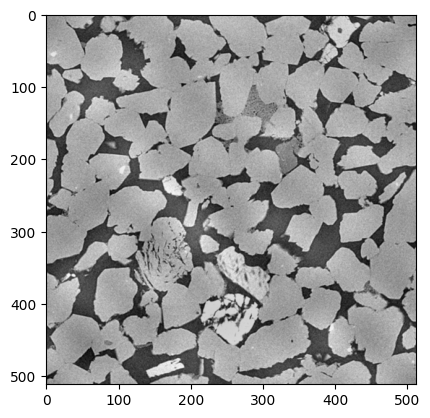

In [21]:
src_in_trg = my_utils.FDA_source_to_target(src_img, trg_img, L = 0.01) 
plt.imshow(src_in_trg[0][0], 'gray')

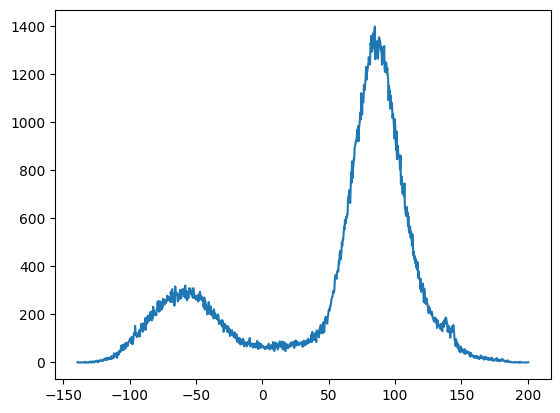

In [33]:
hist = torch.histogram(src_in_trg, bins=1024,  range = None,  weight = None, density = False, out = None)
plt.plot(hist.bin_edges[:-1], hist.hist)

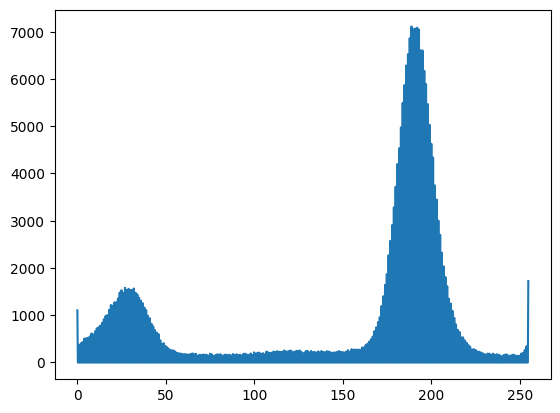

In [36]:
hist = torch.histogram(src_img.float(), bins=1024,  range = None,  weight = None, density = False, out = None)
plt.plot(hist.bin_edges[:-1], hist.hist)

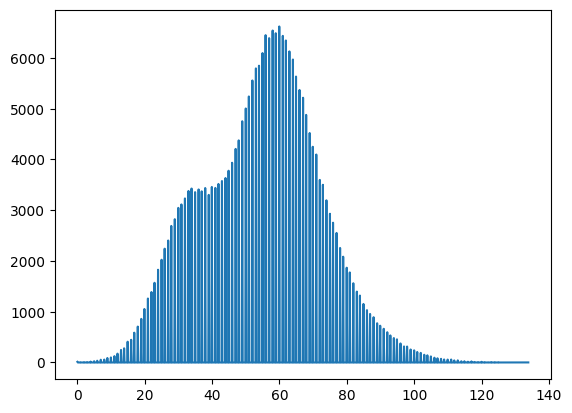

In [37]:
hist = torch.histogram(trg_img.float(), bins=1024,  range = None,  weight = None, density = False, out = None)
plt.plot(hist.bin_edges[:-1], hist.hist)

In [2]:
def normalize_clipped(img, lower_percentile=1, upper_percentile=99):
    low = np.percentile(img, lower_percentile)
    high = np.percentile(img, upper_percentile)
    
    img_clipped = np.clip(img, low, high)
    img_normalized = (img_clipped - low) / (high - low + 1e-8)
    return img_normalized

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Пк\AppData\Local\Temp\ipykernel_4864\1718894101.py:1: SyntaxWarning: invalid escape sequence '\i'
  img = cv2.imread('core_dataset\images\DRP58 2108.png')


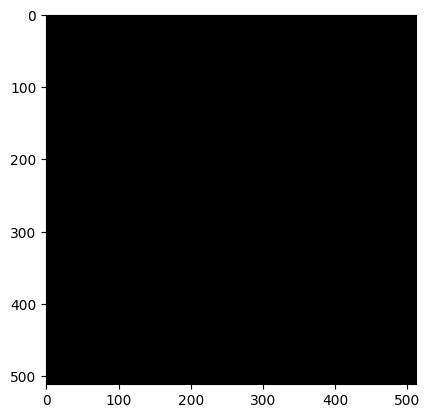

In [3]:
img = cv2.imread('core_dataset\images\DRP58 2108.png')
plt.imshow(img)

In [3]:
DRP58_inputs = []
DRP58_masks = []

files = os.listdir(r'DRP58/input')
N = len(files)
slice = files[N-1000:N]
for file in slice:
    img = cv2.imread(f'DRP58/input/{file}')[:, :, 0]
    DRP58_inputs.append(img)

In [4]:
DRP58_inputs[0].shape

(2000, 2000)

In [5]:
path = "DRP58\Segmented\ES32_HR_1000x1000x1001_8bit.dat"

data = np.fromfile(path, dtype=">u1")

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Пк\AppData\Local\Temp\ipykernel_18208\901172714.py:1: SyntaxWarning: invalid escape sequence '\S'
  path = "DRP58\Segmented\ES32_HR_1000x1000x1001_8bit.dat"


In [21]:
volume = data.reshape((1001, 1000, 1000))
DRP58_masks = np.where(volume[1:] == 9, 0, 1)

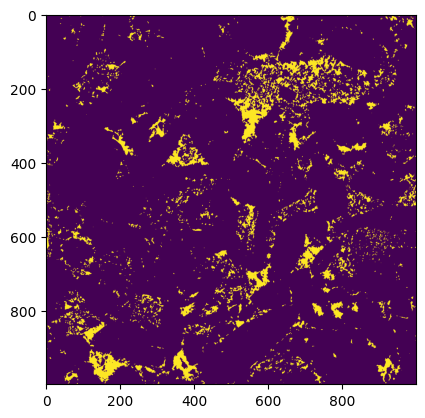

In [22]:
plt.imshow(DRP58_masks[0])

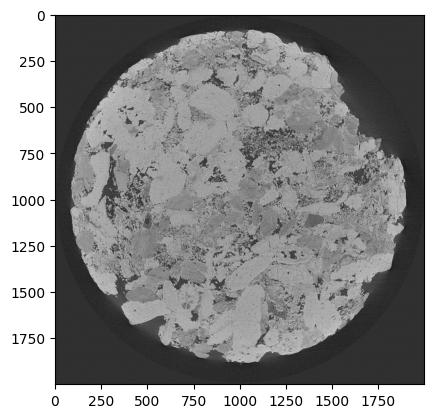

In [24]:
plt.imshow(DRP58_inputs[0], 'gray')

In [25]:
num = 0
for image, mask in zip(DRP58_inputs, DRP58_masks):
    # image = np.abs(image)
    image = normalize_clipped(image)
    c_x = image.shape[0] // 2
    c_y = image.shape[1] // 2
    w = mask.shape[0] // 2
    h = mask.shape[1] // 2
    image = image[(c_x-w):(c_x+w), (c_y-h):(c_y+h)]
    DRP58_inputs[num] = image
    num += 1

In [26]:
DRP58_masks = [my_utils.crop_4(p, 512) for p in DRP58_masks] 
DRP58_inputs = [my_utils.crop_4(p, 512) for p in DRP58_inputs] 

DRP58_masks = [item for sublist in DRP58_masks for item in sublist]
DRP58_inputs = [item for sublist in DRP58_inputs for item in sublist]

In [27]:
len(DRP58_inputs)

4000

In [28]:
num = 0
for image, mask in zip(DRP58_inputs, DRP58_masks):
    # image = np.abs(image)
    im = Image.fromarray(((image / image.max()) * 255).astype('uint8'), mode='L')
    im.save(f'core_dataset/images/DRP58 {num}.png')

    mk = Image.fromarray(mask.astype('uint8'))
    mk.save(f'core_dataset/masks/DRP58 {num}.png')
    num += 1

In [ ]:
bentheimer_masks = xr.open_dataset(r"DRP-421_archive\DRP-421\Bentheimer Sandstone\Bentheimer_Segmentation\BHG1eff_tst_phase.nc")
bentheimer_input = xr.open_dataset(r"DRP-421_archive\DRP-421\Bentheimer Sandstone\Bentheimer_Tomogram\block00000000.nc")
masks = bentheimer_masks['phase'].to_numpy()
inputs = bentheimer_input['tomo'].to_numpy()

In [4]:
bentheimer_input2 = xr.open_dataset(r"DRP-421_archive\DRP-421\Bentheimer Sandstone\Bentheimer_Tomogram\block00000001.nc")
inputs2 = bentheimer_input['tomo'].to_numpy()

In [5]:
bentheimer_inputs = np.abs(np.concatenate([inputs, inputs2], axis = 0))
bentheimer_masks = np.where(masks > 1, 0, 1)

In [6]:
num = 0
for image, mask in zip(bentheimer_inputs, bentheimer_masks):
    # image = np.abs(image)
    image = normalize_clipped(image)
    im = Image.fromarray(((image / image.max()) * 255).astype('uint8'), mode='L')
    im = im.resize([512, 512])
    im.save(f'core_dataset/images/DRP421Bentheimer {num}.png')

    mk = Image.fromarray(mask.astype('uint8'))
    mk = mk.resize([512, 512])
    mk.save(f'core_dataset/masks/DRP421Bentheimer {num}.png')
    num += 1
    

In [7]:
leopard_masks = xr.open_dataset(r"DRP-421_archive\DRP-421\Leopard Sandstone\Leopard_Segmentation\LP_seg_800.nc")
leopard_input1 = xr.open_dataset(r"DRP-421_archive\DRP-421\Leopard Sandstone\Leopard_Tomogram\block00000000.nc")
leopard_input2 = xr.open_dataset(r"DRP-421_archive\DRP-421\Leopard Sandstone\Leopard_Tomogram\block00000001.nc")
masks = leopard_masks['segmented'].to_numpy()
inputs1 = leopard_input1['tomo'].to_numpy()
inputs2 = leopard_input2['tomo'].to_numpy()

In [8]:
leopard_inputs = np.concatenate([inputs1, inputs2], axis = 0)
leopard_masks = np.where(masks > 1, 0, 1)

In [9]:
num = 0
for image, mask in zip(leopard_inputs, leopard_masks):
    # image = np.abs(image)
    image = normalize_clipped(image)
    im = Image.fromarray(((image / image.max()) * 255).astype('uint8'), mode='L')
    im = im.resize([512, 512])
    im.save(f'core_dataset/images/DRP421Leopard {num}.png')

    mk = Image.fromarray(mask.astype('uint8'))
    mk = mk.resize([512, 512])
    mk.save(f'core_dataset/masks/DRP421Leopard {num}.png')
    num += 1
    

In [10]:
label_path = r'6 dataset (160-2560, step=140)\masks (3 classes) (new)'
srez_path = r'6 dataset (160-2560, step=140)\initial images (new)'


files = list(zip(os.listdir(label_path), os.listdir(srez_path)))
n = len(files)

num_classes = 2
image_list = []
target_list = []
for i, (l_p, s_p) in enumerate(files):
    label = cv2.imread(label_path + '/' + l_p)[:, :, 0]
    srez = cv2.imread(srez_path + '/' + s_p)[:, :, 0]

    c_x = srez.shape[0] // 2
    c_y = srez.shape[1] // 2
    w = label.shape[0] // 2
    h = label.shape[1] // 2
    crop_srez = srez[(c_x-w):(c_x+w), (c_y-h):(c_y+h)]
    
    label[label == 2] = 0

    image_list.append(crop_srez)
    target_list.append(label)

In [11]:
beton_masks = [my_utils.crop_4(p, 512) for p in target_list] 
beton_images = [my_utils.crop_4(p, 512) for p in image_list] 

beton_masks = [item for sublist in beton_masks for item in sublist]
beton_images = [item for sublist in beton_images for item in sublist]

In [12]:
num = 0
for image, mask in zip(beton_images, beton_masks):
    # image = np.abs(image)
    im = Image.fromarray(image.astype('uint8'), mode='L')
    im.save(f'core_dataset/images/Beton {num}.png')

    mk = Image.fromarray(mask.astype('uint8'))
    mk.save(f'core_dataset/masks/Beton {num}.png')
    num += 1
    

In [13]:
data3d_images = tiff.imread(r'sandstone_data_for_ML\data_for_3D_Unet\train_images_256_256_256.tif')
data3d_masks = tiff.imread(r'sandstone_data_for_ML\data_for_3D_Unet\train_masks_256_256_256.tif')

In [14]:
num = 0
for image, mask in zip(data3d_images, data3d_masks):
    im = Image.fromarray(image, mode='L')
    im = im.resize([512, 512])
    im.save(f'core_dataset/images/data3d {num}.png')

    mk = np.where(mask > 0, 0, 1)
    mk = Image.fromarray(mk.astype('uint8'))
    mk = mk.resize([512, 512])
    mk.save(f'core_dataset/masks/data3d {num}.png')
    num += 1
    

In [ ]:
np.unique(data3d_masks)

array([0, 1, 2, 3], dtype=uint8)